In [16]:
import matplotlib.pyplot as plt
# from erddapClient import ERDDAP_Griddap
from netCDF4 import Dataset
import numpy as np
import xarray as xr
import cmocean

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib import colors

In [20]:
# Global Ocean Colour (Copernicus-GlobColour), Bio-Geo-Chemical, L4 (monthly and interpolated) from Satellite Observations (Near Real Time)
file_id = Dataset('../../data/chl/climate_slope/chla_day_summer_mean_20260403.nc')
ras = file_id.variables["CHL_anom_mean"][:]
#mask = file_id.variables["mask"][:]
lat = file_id.variables["latitude"][:]
lon = file_id.variables["longitude"][:]
file_id.close()

In [9]:

ras.min()

<xarray.DataArray ()> Size: 4B
array(0.00478214, dtype=float32)

In [21]:

# convert to xarray. 
ras = xr.DataArray(ras, 
                   coords={'x': lat, 'y':lon}, 
                   dims=["x", "y"])

# fudging the nubers to get the colormap nice. 
# ras_colorbar = ras.clip(min = 0, max = 0.012, keep_attrs=False)
# ras = ras.clip(min = -0.006, max = 0.007, keep_attrs=False)
ras = ras.clip(min = 0.004, max = 0.13, keep_attrs=False)
# ras_f = ras.clip(min=0, max=, keep_attrs=True)
# ras_f = ras_f.fillna(np.nanmax(ras_f.values))

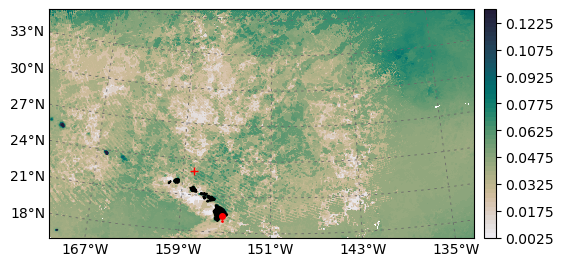

In [22]:
#divnorm = colors.TwoSlopeNorm(vmin = np.nanmin(ras.data), vcenter = 0, vmax = np.nanmax(ras.data))

# Calculate the bounds of the data
lon_bounds = [ras.y.min(), ras.y.max()]
lat_bounds = [ras.x.min(), ras.x.max()]

# AGU max dim 6.7 x 8.9
fig, (ax1) = plt.subplots(1, 1, figsize=(6.6, 5.5))
m = Basemap(projection='lcc', resolution='h', 
            llcrnrlat=16, urcrnrlat=35.5, 
            llcrnrlon=-170, urcrnrlon=-130,
            lat_0 = 30, lon_0 = -150,
            width=5.1E6, height=5E6)

# Convert latitude and longitude to map projection coordinates.
x_map, y_map = np.meshgrid(ras.y, ras.x)
x, y = m(x_map, y_map)
# Plot data.
contour = m.contourf(x, y, ras, cmap = cmocean.cm.rain, levels=100, extend='both') # , norm=divnorm)
m.fillcontinents(color = 'black')
# Add grid lines
parallels = m.drawparallels(np.arange(18, 40, 3), labels=[1,0,0,0], textcolor = 'black', color = "dimgrey", fontsize=10, dashes=(3, 5), linewidth = 0.6)
meridians =  m.drawmeridians(np.arange(-175, -130, 8), labels=[0,0,0,1], textcolor = 'black', color = "dimgrey", fontsize=10, dashes=(3, 5),linewidth = 0.6)
# Draw parallels and meridians with customized gridline alpha and label colors
m.drawcoastlines(color='black')

# Plot Station Aloha (23N, 158W)
xa, ya = m(-158, 23)
m.plot(xa, ya, marker='+', color='red', markersize=6, label='Stn. ALOHA', linestyle='None')
# Plot Seamount  18.92, -155.27 (19N, 155W)
xs, ys = m(-155.27, 18.92)
m.plot(xs, ys, marker='.', color='red', markersize=2, label='Kamaʻehuakanaloa', linestyle='None')
# Plot Seamount Mnt. K (19.406893, -155.283386)
xs, ys = m(-155.283386, 19.406893)
m.plot(xs, ys, marker='o', color='red', markersize=4, label='Kilauea', linestyle='None')

# add colorbar.
c = ax1.contourf(ras.y, ras.x, ras, levels = 50, cmap = cmocean.cm.rain)#, norm=divnorm)
cbar = fig.colorbar(c, shrink = 0.54, pad = 0.02)
# plt.title("Summertime mean chlorophyll anomaly from 1997 to 2023 [$mg$ $m^{-3}$]")
#plt.savefig('../../figures/climatology_chl_20260315.png', bbox_inches='tight', dpi=600)
#plt.savefig('../../figures/climatology_chl_20260315.pdf', bbox_inches='tight', dpi=600)
plt.show()